In [1]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [2]:
## time estimation
from tqdm import tqdm
import time

all_times = []

for i_agent in tqdm(range(30)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(i_agent + 1),
    )

    self.load_model()

    np.random.seed(i_agent)
    torch.manual_seed(i_agent)
    self.env.generate_test_task(num_tasks=100, num_trials=500)
    start_time = time.time()
    result = self.evaluate()
    end_time = time.time()
    all_times.append(end_time - start_time)

print(f"Time taken: mean {np.mean(all_times)} seconds, std {np.std(all_times)} seconds")

100%|██████████| 30/30 [01:29<00:00,  2.99s/it]

Time taken: mean 2.0637712399164836 seconds, std 0.09141621327922783 seconds


In [18]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.05, 0.1, 0.15, 0.2, 0.25]
range_of_taus = [0.0, 0.01, 0.03, 0.05, 0.1]
range_of_ffs = [0.01, 0.03, 0.05, 0.07, 0.1, 0.13, 0.15, 0.2, 0.25]

nb_tasks = 5000
vols_grid, ffs_grid, taus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_taus, indexing='ij')
vols, ffs, taus = vols_grid.ravel(), ffs_grid.ravel(), taus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
taus = np.tile(taus, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

In [19]:
from tqdm import tqdm
nb_agents = 30
nb_trials = 200
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, nb_simuls))
rewards = np.zeros((nb_agents, 3))
probas_association = np.zeros((nb_agents, nb_tasks, nb_trials, 4))
probas_ffs = np.zeros((nb_agents, nb_tasks, nb_trials))
probas_transition = np.zeros((nb_agents, nb_tasks, nb_trials))

performances_nb_cues = np.zeros((nb_agents, 4))
averages = np.zeros((nb_agents, nb_tasks, nb_trials))

for i_agent in tqdm(range(nb_agents)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(i_agent + 1),
    )

    self.load_model()

    np.random.seed(0)    
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=nb_trials, num_steps=13, variable_length=True, nus=vols, ffs=ffs, taus=taus)
    nb_cues_presented = (self.env.context != -1).sum(axis=-1)

    result = self.evaluate(KO_transition=False)
    probas_association[i_agent] = result['probas_association'].detach().numpy()
    probas_ffs[i_agent] = result['probas_emission'][:, :, :100].sum(axis=-1).detach().numpy()
    probas_transition[i_agent] = result['probas_transition'].detach().numpy()

    performances[i_agent] = (result['selected_actions'].numpy() == self.env.correct_arms).mean(axis=1)
    averages[i_agent] = np.sum(result['probas_emission'].detach().numpy() * np.arange(-1, 1.01, 0.01)[None, None], axis=-1)

100%|██████████| 30/30 [25:28<00:00, 50.93s/it]


### Test

In [35]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
from tqdm import tqdm
nb_tasks = 5000
nb_agents = 30
nb_trials = 200
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, 3))

for i_agent in tqdm(range(nb_agents)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(i_agent + 1),
    )

    self.load_model()

    np.random.seed(0)
    self.env.generate_test_task(num_tasks=nb_tasks, num_trials=nb_trials, num_steps=10, variable_length=True, nb_steps_increment=3) #, ffs=ffs)
    nb_cues_presented = (self.env.context != -1).sum(axis=-1)

    result = self.evaluate(KO_transition=False)

    for idx_ko in range(3):
        if idx_ko == 0:
            result = self.evaluate(KO_transition=False)
        elif idx_ko == 1:
            result = self.evaluate(KO_transition=True)
        else:
            result = self.evaluate(KO_WP=True)
        performances[i_agent, idx_ko] = (result['selected_actions'].numpy() == self.env.correct_arms).mean()

100%|██████████| 30/30 [1:17:26<00:00, 154.88s/it]


(0.0, 1.0)

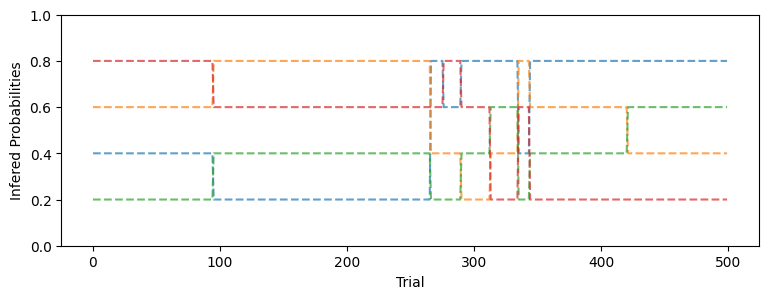

In [ ]:
self.env.generate_test_task(num_tasks=10, num_trials=500, num_steps=0, probas=None, variable_length=False, taus=[0.01] * 10)

plt.figure(figsize=(9, 3))
for i in range(4):
    plt.plot(self.env.probas[0, :, i], linestyle='--', alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
plt.ylabel('Infered Probabilities')
plt.xlabel('Trial')
plt.gca().set_ylim(0, 1)
plt.savefig('figures/WP_trials_example_new.pdf')
plt.gca().set_ylim(0, 1)

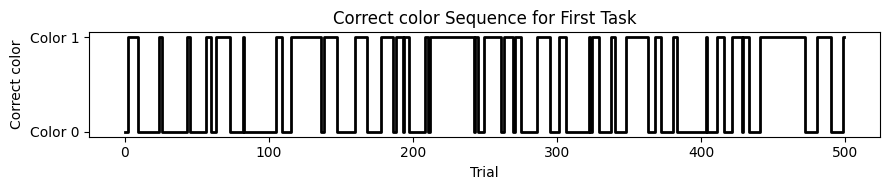

In [5]:
plt.figure(figsize=(9, 2))
plt.plot(self.env.correct_arms[0], drawstyle='steps-post', color='black', linewidth=2)
plt.title('Correct color Sequence for First Task')
plt.xlabel('Trial')
plt.ylabel('Correct color')
plt.yticks(np.arange(2), ["Color 0", "Color 1"])
plt.tight_layout()
plt.savefig('figures/WP_trials_correct_arms_example.pdf')
plt.show()

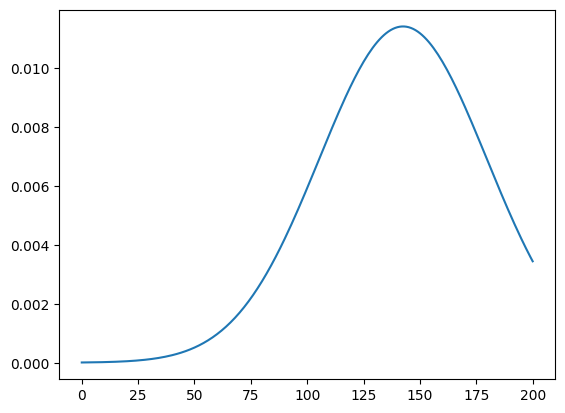

In [6]:
plt.plot(self.env.p_gen[0])

### Performance with and without KO

In [36]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.05, 0.1, 0.15, 0.2, 0.25]
range_of_taus = [0.0, 0.01]
range_of_ffs = [0.1, 0.15, 0.2, 0.25, 0.3]

nb_tasks = 4000
vols_grid, ffs_grid, taus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_taus, indexing='ij')
vols, ffs, taus = vols_grid.ravel(), ffs_grid.ravel(), taus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
taus = np.tile(taus, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

In [47]:
from tqdm import tqdm
nb_agents = 30
nb_tasks = 5000
nb_trials = 200
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, 3))
rewards = np.zeros((nb_agents, 3))
probas_association = np.zeros((nb_agents, nb_tasks, nb_trials, 4))
probas_ffs = np.zeros((nb_agents, nb_tasks, nb_trials))
probas_transition = np.zeros((nb_agents, nb_tasks, nb_trials))

performances_nb_cues = np.zeros((nb_agents, 3, 4))
rewards_nb_cues = np.zeros((nb_agents, 3, 4))

for i_agent in tqdm(range(nb_agents)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(i_agent + 1),
    )

    self.load_model()

    np.random.seed(0)    
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=nb_trials, num_steps=10, variable_length=True, nb_steps_increment=3)
    nb_cues_presented = (self.env.context != -1).sum(axis=-1)

    for idx_ko in range(3):
        if idx_ko == 0:
            result = self.evaluate(KO_transition=False)
            probas_association[i_agent] = result['probas_association'].detach().numpy()
            probas_ffs[i_agent] = result['probas_emission'][:, :, :100].sum(axis=-1).detach().numpy()
            probas_transition[i_agent] = result['probas_transition'].detach().numpy()
        elif idx_ko == 1:
            result = self.evaluate(KO_transition=True)
        else:
            result = self.evaluate(KO_WP=True)
        performances[i_agent, idx_ko] = (result['selected_actions'].numpy() == self.env.correct_arms).mean()

        for idx_nb_cues, nb_cues in enumerate([0, 3, 6, 9]):
            performances_nb_cues[i_agent, idx_ko, idx_nb_cues] = (result['selected_actions'].numpy() == self.env.correct_arms)[nb_cues_presented == nb_cues].mean()

100%|██████████| 30/30 [32:14<00:00, 64.47s/it]


In [48]:
import pickle
with open('results/performances_optimal.pkl', 'rb') as f:
    [all_map_particles, prediction_weather, association_probs_trials, polarity_particles, correct_response] = pickle.load(f)


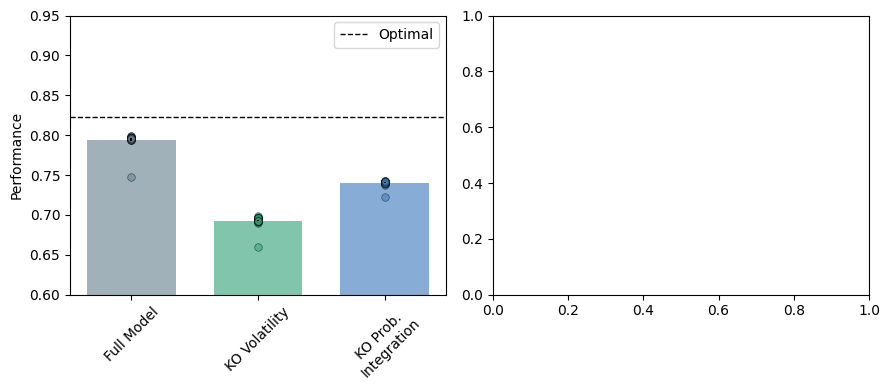

In [49]:

import matplotlib.pyplot as plt

# Define colors
colors = ['#617D8C', '#2EA076', '#3877BC']

# Calculate means and standard errors
perf_means = performances.mean(axis=0)
perf_sems = performances.std(axis=0) / np.sqrt(performances.shape[0])

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
x = np.arange(3)
width = 0.7

# Plot performance bars
bars1 = ax1.bar(x, perf_means, width, yerr=perf_sems, capsize=0, 
              color=colors, alpha=0.6)

# Plot performance individual points
for i in range(3):
    ax1.scatter(np.repeat(i, performances.shape[0]), performances[:, i], 
               alpha=0.5, color=colors[i], s=30, edgecolor='black', linewidth=0.5)

# Plot horizontal dashed line at correct_response.mean()
ax1.axhline(correct_response.mean(), color='black', linestyle='dashed', linewidth=1,
            label='Optimal')

# Customize performance plot
ax1.set_xticks(x)
ax1.set_xticklabels(['Full Model', 'KO Volatility', 'KO Prob.\nIntegration'], rotation=45)
ax1.set_ylabel('Performance')
ax1.set_ylim([0.6, 0.95])
ax1.legend()

plt.tight_layout()

#plt.savefig('figures/WP_bandit_performance_apri_2026.pdf')
plt.show()

In [50]:
performances.mean(axis=0)

array([0.79436342, 0.69298358, 0.74021321])

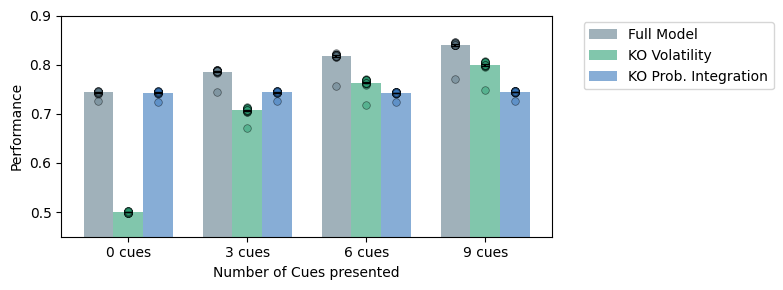

In [20]:
# Plot performances for different number of cues and models
plt.figure(figsize=(8, 3))

# Calculate means and standard errors across agents
perf_means = performances_nb_cues.mean(axis=0)  # Shape: (3 KO types, 3 cue numbers)
perf_sems = performances_nb_cues.std(axis=0) / np.sqrt(performances_nb_cues.shape[0])

# Plot bars for each model type
x = np.arange(4)  # For the 3 cue conditions
width = 0.25  # Width of bars
colors = ['#617D8C', '#2EA076', '#3877BC'] # Colors for different models
labels = ['Full Model', 'KO Volatility', 'KO Prob. Integration']

for i in range(3):  # For each model type
    offset = (i - 1) * width
    plt.bar(x + offset, perf_means[i], width, 
            yerr=perf_sems[i], capsize=3,
            color=colors[i], alpha=0.6,
            label=labels[i])
    
    # Plot individual points
    for j in range(4):  # For each cue number
        plt.scatter(np.repeat(x[j] + offset, performances_nb_cues.shape[0]), 
                   performances_nb_cues[:, i, j],
                   alpha=0.5, color=colors[i], s=30, 
                   edgecolor='black', linewidth=0.5)

# Customize plot
plt.xticks(x, ['0 cues', '3 cues', '6 cues', '9 cues'])
plt.ylabel('Performance')
plt.ylim([0.45, 0.9])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Number of Cues presented')

plt.tight_layout()
plt.savefig('figures/WP_bandit_performance_nb_cues_april_2025.pdf')
plt.show()

### Estimation of volatility

In [26]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [25]:
import numpy as np
from tqdm import tqdm

# Define the parameter ranges
#range_of_vols = [0.05, 0.1, 0.15, 0.2, 0.25]
#range_of_taus = [0.0, 0.01]
#range_of_ffs = [0.1, 0.15, 0.2, 0.25, 0.3]

range_of_vols = [0.1, 0.15, 0.2, 0.25, 0.3]
range_of_taus = [0.0, 0.01]
range_of_ffs = [0.05]

nb_tasks = 500
vols_grid, ffs_grid, taus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_taus, indexing='ij')
vols, ffs, taus = vols_grid.ravel(), ffs_grid.ravel(), taus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
taus = np.tile(taus, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

In [26]:
nb_agents = 30
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, 3))
rewards = np.zeros((nb_agents, 3))
probas_association = np.zeros((nb_agents, nb_tasks, 500, 4))
probas_ffs = np.zeros((nb_agents, nb_tasks, 500))
probas_transition = np.zeros((nb_agents, nb_tasks, 500))

performances_nb_cues = np.zeros((nb_agents, 3, 4))
rewards_nb_cues = np.zeros((nb_agents, 3, 4))

for i_agent in tqdm(range(nb_agents)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(i_agent + 1),
    )

    self.load_model()

    np.random.seed(i_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, taus=taus, variable_length=False, nus=vols, ffs=ffs)

    result = self.evaluate()
    probas_association[i_agent] = result['probas_association'].detach().numpy()
    probas_ffs[i_agent] = result['probas_emission'][:, :, :100].sum(axis=-1).detach().numpy()
    probas_transition[i_agent] = result['probas_transition'].detach().numpy()

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [07:52<00:00, 15.74s/it]


/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_3844/3491460749.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white


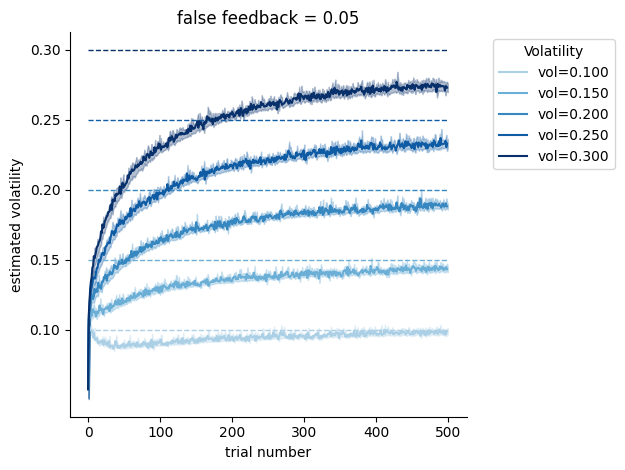

In [28]:
unique_vols = np.unique(vols)
estimations_means = np.hstack([probas_transition[:, (vols==v)].mean(axis=1, keepdims=True) for v in unique_vols])

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create a colormap with as many shades as unique_vols
cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white

fig, ax = plt.subplots()
for i in range(estimations_means.shape[1]):
    color = cmap(i + 2)  # skip the lightest colors
    ax.plot(estimations_means[:, i, 1:500].mean(axis=0), color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.fill_between(np.arange(1, 500), 
        estimations_means[:, i, 1:500].mean(axis=0) - estimations_means[:, i, 1:500].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:500].mean(axis=0) + estimations_means[:, i, 1:500].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    ax.plot([0, 500], [unique_vols[i], unique_vols[i]], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('True volatility')
ax.legend(title="Volatility", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('trial number')
ax.set_ylabel('estimated volatility')
ax.set_title('false feedback = 0.05')
ax.set_yticks(unique_vols)
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/volatility_trial_number_april_2026.pdf')

### Estimation du false feedback

In [29]:
import numpy as np
from tqdm import tqdm

# Define the parameter ranges

range_of_vols = [0.05]
range_of_taus = [0.0, 0.01]
range_of_ffs = [0.05, 0.1, 0.15, 0.2, 0.25]

nb_tasks = 500
vols_grid, ffs_grid, taus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_taus, indexing='ij')
vols, ffs, taus = vols_grid.ravel(), ffs_grid.ravel(), taus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
taus = np.tile(taus, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

In [30]:
nb_agents = 30
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, 3))
rewards = np.zeros((nb_agents, 3))
probas_association = np.zeros((nb_agents, nb_tasks, 500, 4))
probas_ffs = np.zeros((nb_agents, nb_tasks, 500))
probas_transition = np.zeros((nb_agents, nb_tasks, 500))

performances_nb_cues = np.zeros((nb_agents, 3, 4))
rewards_nb_cues = np.zeros((nb_agents, 3, 4))

for i_agent in tqdm(range(nb_agents)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(i_agent + 1),
    )

    self.load_model()

    np.random.seed(i_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, taus=taus, variable_length=False, nus=vols, ffs=ffs)

    result = self.evaluate()
    probas_association[i_agent] = result['probas_association'].detach().numpy()
    probas_ffs[i_agent] = result['probas_emission'][:, :, :100].sum(axis=-1).detach().numpy()
    probas_transition[i_agent] = result['probas_transition'].detach().numpy()

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [07:15<00:00, 14.53s/it]


ValueError: operands could not be broadcast together with shapes (499,) (199,) 

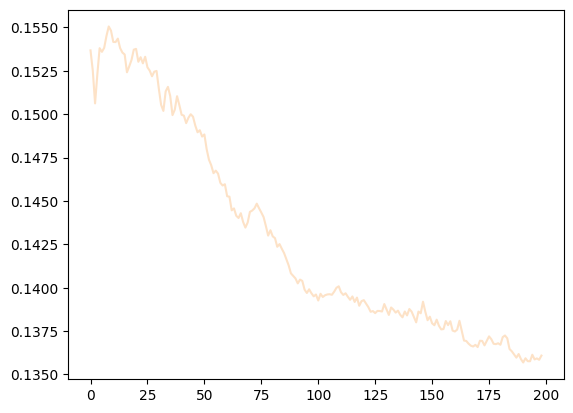

In [51]:
unique_falsefeedback = np.unique(ffs)
estimations_means = np.hstack([probas_ffs[:, (ffs==v) * (vols==0.05)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, 1:500].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, 500), 
        estimations_means[:, i, 1:].mean(axis=0) - estimations_means[:, i, 1:].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:].mean(axis=0) + estimations_means[:, i, 1:].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, 500], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
ax.set_title('vol = 0.05')
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/falsefeedback_trial_number_april_2026.pdf')

### WP reversals

In [33]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))

itrial = 300

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "bandit_WP_GRU_id{0}".format(idx_agent + 1),
    )

    self.load_model()

    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, taus=[0.0] * nb_simuls)
    initial_probas = self.env.probas.copy()
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, taus=[0.0] * nb_simuls)
    result2 = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = np.swapaxes(result2['probas_association'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    result1 = self.evaluate()
    association_probs_reversals[idx_agent] = np.swapaxes(result1['probas_association'][np.arange(nb_simuls)[:, None], :, indexes_sorted].detach().numpy(), 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(result1['probas'][np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

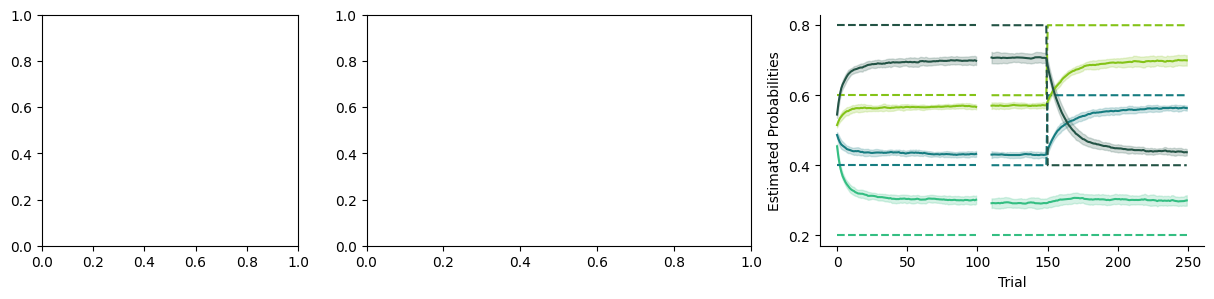

In [34]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})

# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/bandit_WP_reversal_april2026.pdf')

plt.show()